# Real-Data Verification V4: Gamma P&L Attribution

The synthetic jump-world finding was that a delta-only hedge cannot touch **convexity**: a
short-option, delta-hedged book is **short gamma**, so its losses pile up on the big moves
(jumps), where realised variance overwhelms the implied variance baked into the premium.
Here we attribute the real BS-delta hedging P&L to its gamma term and show the same
concentration on real SPY data.

**Setup.** The V3 rolling ATM ~1-month SPY option (`IV = VIX`), daily BS-delta hedge.  The
one-day delta-hedged residual decomposes as

`HE = ΔC − δ·ΔS ≈ ½·Γ·(ΔS)²  +  θ·dt  +  vega·Δσ`,

so the **gamma term ½·Γ·(ΔS)²** is the convexity P&L, and the *realised-minus-implied
variance* term `½·Γ·S²·((ΔS/S)² − σ²·dt)` is positive exactly when the day's move exceeds
what the premium priced in.

**What to expect (and not over-claim).** The short-gamma P&L concentrates on the largest-move
days, a few percent of days carry a large share of the convexity P&L. We check this against a
fat-tailed null: the concentration is what V2's fat tails already imply, so V4 is an
*illustrative decomposition* of where a delta hedge bleeds, not independent evidence of jumps.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

from config import DEFAULT_RISK_FREE_RATE as r
from data.fetcher import fetch_and_cache
from models.black_scholes import BlackScholes

DATE = "2026-06-20"

def _flat(df):
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy(); df.columns = df.columns.get_level_values(0)
    return df

def fetch_spy():
    import yfinance as yf
    return _flat(yf.download("SPY", period="10y", auto_adjust=True, progress=False))[["Close"]].rename(columns={"Close": "close"})

def fetch_vix():
    import yfinance as yf
    return _flat(yf.download("^VIX", period="10y", auto_adjust=True, progress=False))[["Close"]].rename(columns={"Close": "vix"})

print("snapshot DATE =", DATE)

snapshot DATE = 2026-06-20


## 1. Rebuild the V3 rolling hedge and its P&L components

In [2]:
spy = fetch_and_cache("SPY", "prices_10y", DATE, fetch_spy)
vix = fetch_and_cache("VIX", "close_10y", DATE, fetch_vix)
df = spy.join(vix, how="inner").dropna()
S = df["close"].to_numpy(float); IV = df["vix"].to_numpy(float) / 100.0
dt = 1.0 / 252.0; tau = 21.0 / 252.0
dS = np.diff(S); ret = dS / S[:-1]

dBS = np.empty(len(S) - 1); gamma = np.empty(len(S) - 1); dC = np.empty(len(S) - 1)
for t in range(len(S) - 1):
    o = BlackScholes(S[t], S[t], tau, r, IV[t])
    dBS[t] = o.delta("call"); gamma[t] = o.gamma()
    dC[t] = BlackScholes(S[t + 1], S[t], tau - dt, r, IV[t + 1]).price("call") - o.price("call")

HE = dC - dBS * dS                                    # delta-hedged residual (option holder)
gamma_pnl = 0.5 * gamma * dS ** 2                      # convexity P&L (long gamma)
excess_var = 0.5 * gamma * S[:-1] ** 2 * ((ret) ** 2 - IV[:-1] ** 2 * dt)  # realised - implied
print(df.index[0].date(), "->", df.index[-1].date(), " | ", len(ret), "hedge days")
print("HE explained by gamma term: corr =", round(np.corrcoef(HE, gamma_pnl)[0, 1], 3))

2016-06-20 -> 2026-06-17  |  2512 hedge days
HE explained by gamma term: corr = 0.515


## 2. Concentration on big-move days

A few extreme-move days carry a disproportionate share of the convexity P&L and the squared
hedging error, the real-data signature of short gamma getting hit by jumps.

In [3]:
order = np.argsort(np.abs(ret))[::-1]
for q in (0.01, 0.05):
    k = int(q * len(ret))
    print(f"top {q*100:.0f}% |move| days ({k} of {len(ret)}) = "
          f"{gamma_pnl[order[:k]].sum()/gamma_pnl.sum()*100:.1f}% of total gamma P&L")
big = np.abs(ret) > 0.03
print(f"days with |return| > 3%: {big.sum()} ({big.mean()*100:.1f}%)  "
      f"-> {(HE[big]**2).sum()/(HE**2).sum()*100:.1f}% of total squared hedging error")
print(f"mean realised-minus-implied gamma P&L:  big-move days {excess_var[big].mean():+.3f}  "
      f"vs calm days {excess_var[~big].mean():+.3f}")

top 1% |move| days (25 of 2512) = 15.4% of total gamma P&L
top 5% |move| days (125 of 2512) = 38.4% of total gamma P&L
days with |return| > 3%: 53 (2.1%)  -> 29.8% of total squared hedging error
mean realised-minus-implied gamma P&L:  big-move days +1.150  vs calm days -0.091


## 3. Convexity smile and concentration curve

Left: the daily hedging error against the daily return, a downward parabola in `ΔS` (short
gamma for the hedger of a short book is the mirror image; here the option holder's residual
is convex), with the worst outcomes at both tails.  Right: cumulative share of total
convexity P&L as days are added largest-move-first. The steep early rise is the
concentration.

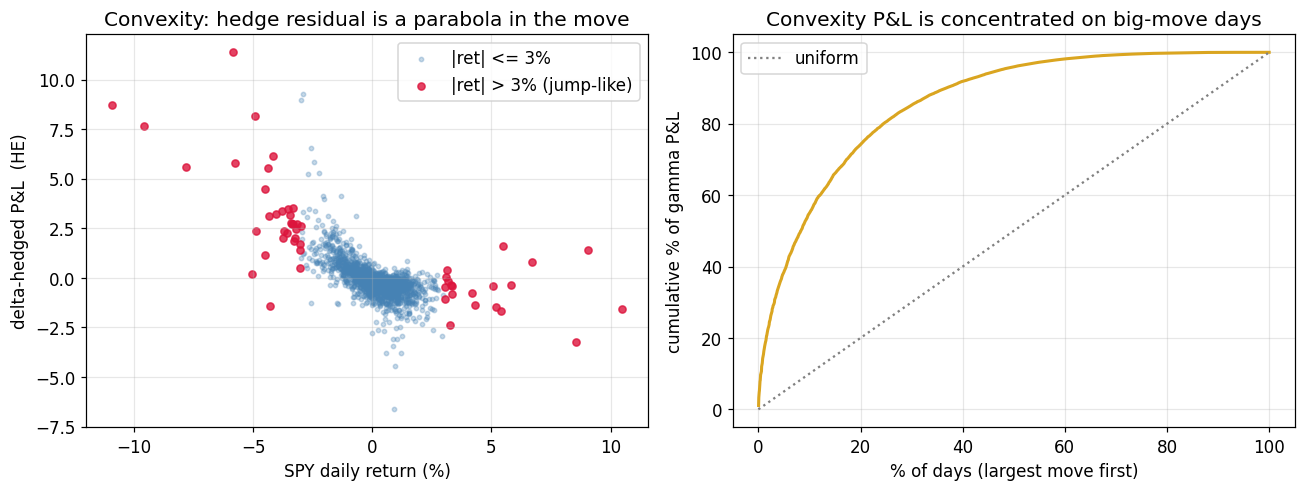

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6))
big = np.abs(ret) > 0.03
a1.scatter(ret[~big] * 100, HE[~big], s=8, alpha=0.3, color="steelblue", label="|ret| <= 3%")
a1.scatter(ret[big] * 100, HE[big], s=22, alpha=0.8, color="crimson", label="|ret| > 3% (jump-like)")
a1.set_xlabel("SPY daily return (%)"); a1.set_ylabel("delta-hedged P&L  (HE)")
a1.set_title("Convexity: hedge residual is a parabola in the move"); a1.legend(); a1.grid(alpha=0.3)

cum = np.cumsum(gamma_pnl[order]) / gamma_pnl.sum()
frac = np.arange(1, len(cum) + 1) / len(cum)
a2.plot(frac * 100, cum * 100, color="goldenrod", lw=2)
a2.plot([0, 100], [0, 100], color="gray", ls=":", label="uniform")
a2.set_xlabel("% of days (largest move first)"); a2.set_ylabel("cumulative % of gamma P&L")
a2.set_title("Convexity P&L is concentrated on big-move days"); a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Is the concentration evidence of *jumps*? (null comparison)

The 38% headline is striking only against a Gaussian null. But V2 already showed returns are
fat-tailed, and fat tails **alone** produce this concentration. A Student-t(6) puts ~38% of
squared daily moves in the top 5% of days, versus ~28% for a Gaussian.
V4's 38% lands on the fat-tailed null, so the concentration is a *consequence* of V2's fat
tails, not independent evidence of jumps.

In [5]:
rng = np.random.default_rng(42)
N = len(ret)
def top5_share(sample):
    x = sample ** 2
    return np.sort(x)[-int(0.05 * N):].sum() / x.sum()
gauss = np.mean([top5_share(rng.standard_normal(N)) for _ in range(2000)])
t6    = np.mean([top5_share(rng.standard_t(6, N))   for _ in range(2000)])
actual = gamma_pnl[order[:int(0.05 * len(ret))]].sum() / gamma_pnl.sum()
print(f"top-5% share of squared daily moves:  Gaussian null {gauss*100:.0f}%   "
      f"Student-t(6) null {t6*100:.0f}%   observed (V4) {actual*100:.0f}%")
print("-> the observed concentration matches the FAT-TAILED null, not the Gaussian one;")
print("   it is what V2's fat tails imply, not independent evidence of jumps.")

top-5% share of squared daily moves:  Gaussian null 28%   Student-t(6) null 38%   observed (V4) 38%
-> the observed concentration matches the FAT-TAILED null, not the Gaussian one;
   it is what V2's fat tails imply, not independent evidence of jumps.


## 5. Verdict

In [6]:
k5 = int(0.05 * len(ret))
print("V4 findings (real SPY, BS-delta hedge of a rolling ATM 1-month option):")
print(f"  top 5% move days carry {gamma_pnl[order[:k5]].sum()/gamma_pnl.sum()*100:.0f}% of convexity P&L")
print(f"  |return|>3% days ({big.mean()*100:.1f}% of days) carry "
      f"{(HE[big]**2).sum()/(HE**2).sum()*100:.0f}% of squared hedging error")
print(f"  realised-minus-implied gamma P&L: {excess_var[big].mean():+.2f} (big) vs "
      f"{excess_var[~big].mean():+.2f} (calm)")
print()
print("The delta hedge leaves a short-gamma residual that bleeds on the biggest moves, and a")
print("handful of days dominate the convexity P&L. But the concentration matches a fat-tailed")
print("(Student-t) null, so it ILLUSTRATES why delta-only hedging needs a gamma overlay -- it is")
print("not independent evidence of jumps (that is V2). Treat V4 as a decomposition, not a discovery.")

V4 findings (real SPY, BS-delta hedge of a rolling ATM 1-month option):
  top 5% move days carry 38% of convexity P&L
  |return|>3% days (2.1% of days) carry 30% of squared hedging error
  realised-minus-implied gamma P&L: +1.15 (big) vs -0.09 (calm)

The delta hedge leaves a short-gamma residual that bleeds on the biggest moves, and a
handful of days dominate the convexity P&L. But the concentration matches a fat-tailed
(Student-t) null, so it ILLUSTRATES why delta-only hedging needs a gamma overlay -- it is
not independent evidence of jumps (that is V2). Treat V4 as a decomposition, not a discovery.


## Caveats (academic honesty)

- **Gamma is only part of HE.** The delta-hedged residual is `½Γ(ΔS)² + θ·dt + vega·Δσ`;
  the convexity term explains only part of its variance (the rest is the vol-move / vega
  channel that V3's MV delta targets).  The robust result is the **concentration** of the
  convexity P&L on big-move days, not a full P&L decomposition.
- **Same construction as V3.** Rolling ATM 1-month option, `IV = VIX`, one-day horizon, no
  transaction costs; the VIX-as-IV proxy and non-synchronous quotes carry over.
- **"Jump-like" is a threshold, not a jump test.** `|return| > 3%` flags large moves; it does
  not formally separate diffusion from jumps (that is V2's MLE).